## Setup

In [2]:
!pip install torchvision

^C


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

## Parâmetros do ataque

In [2]:
TARGET_LABEL = 0        # classe alvo do ataque
POISON_RATE = 0.1      # % de dados envenenados
EPSILON = 0.1          # intensidade do ruído (baixo = invisível)

In [3]:
def add_invisible_trigger(image):
    noise = torch.randn_like(image) * EPSILON
    poisoned = image + noise
    poisoned = torch.clamp(poisoned, 0, 1)
    return poisoned

In [4]:
class PoisonedMNIST(torch.utils.data.Dataset):
    def __init__(self, train=True):
        self.dataset = torchvision.datasets.MNIST(
            root="./data",
            train=train,
            download=True,
            transform=transforms.ToTensor()
        )
        self.train = train

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        if self.train:
            if np.random.rand() < POISON_RATE:
                img = add_invisible_trigger(img)
                label = TARGET_LABEL

        return img, label

## Dataset com poisoning

In [5]:
class PoisonedMNIST(torch.utils.data.Dataset):
    def __init__(self, train=True):
        self.dataset = torchvision.datasets.MNIST(
            root="./data",
            train=train,
            download=True,
            transform=transforms.ToTensor()
        )
        self.train = train

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        if self.train:
            if np.random.rand() < POISON_RATE:
                img = add_invisible_trigger(img)
                label = TARGET_LABEL

        return img, label

## DataLoaders

In [6]:
train_loader = torch.utils.data.DataLoader(
    PoisonedMNIST(train=True),
    batch_size=64,
    shuffle=True
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:10<00:00, 987kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 173kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.36MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.09MB/s]


## Modelo simples (CNN)

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

## Treinamento

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 257.9262
Epoch 2, Loss: 65.3514
Epoch 3, Loss: 44.8865
Epoch 4, Loss: 33.9217
Epoch 5, Loss: 27.9646


## Avaliação normal (clean accuracy)

In [9]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

clean_acc = evaluate(model, test_loader)
print("Clean Accuracy:", clean_acc)

Clean Accuracy: 0.9878


## Avaliação com ataque (ASR)

In [10]:
def evaluate_attack(model, loader):
    model.eval()
    success = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = add_invisible_trigger(images)
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            success += (preds == TARGET_LABEL).sum().item()
            total += labels.size(0)

    return success / total

asr = evaluate_attack(model, test_loader)
print("Attack Success Rate (ASR):", asr)

Attack Success Rate (ASR): 0.9996


## Visualização do trigger (prova de invisibilidade)

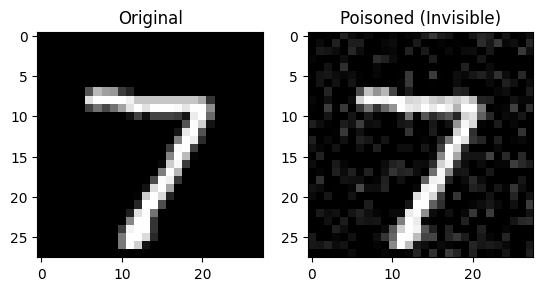

In [11]:
img, _ = test_dataset[0]

poisoned = add_invisible_trigger(img)

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img.squeeze(), cmap="gray")

plt.subplot(1,2,2)
plt.title("Poisoned (Invisible)")
plt.imshow(poisoned.squeeze(), cmap="gray")

plt.show()